# Requested apodization and fiber

In [1]:
import numpy as nnp

#Entrance beam
En_diam = 10e-3  #Beam diameter [m]
En_rad = En_diam/2

#Exit apodized beam
apodized = True
Ex_diam = 5e-3 #Beam diameter [m]
Ex_rad = Ex_diam/2

n = 500   #Sampling

# Definition of the wavelength for the monochromatic study
Wave_mono = True
w_mono = 4e-6 # [m] wavelength in the case of a monochromatic study

# Definition of the fiber's MFD to calculate coupling efficiency
mfd = 22e-6  #[m]

# Ideal focal length to use
focal_length = nnp.pi * Ex_diam * mfd / (4 * w_mono)  #[m]
if apodized == False:
    focal_length *= 1/1.1209
print(f"Ideal Focal Length: {focal_length*1e3:.6f} mm")

# Factor of PSF size for sampling of the image plane, 10 is better to plot it, 50 is better to calculate the coupling efficiency
n_pix_oversample = 50

Ideal Focal Length: 21.598449 mm


# Implementation of Guyon 2003 differential equation

$$ \frac{d M_1(r_1(t))}{d r_1(t)} = \frac{d M_2(r_2(t))}{d r_2(t)} = \frac{\sqrt{A(t)^2 + B(t)^2} - B(t)}{A(t)} $$

with

$ A(t) = r_2(t) - r_1(t) $

$ B(t) = M_2(r_2(t)) - M_1(r_1(t)) $

In [2]:
import numpy as nnp
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy.integrate as integrate
import scipy.optimize as optimize
import scipy.differentiate as diff
from scipy import special
#import pandas as pd
from astropy import modeling

## Definition of entrance and exit pupil

0.9979959919839677
0.9979886339104327


"\ndef r2_v2(t):\n    return nnp.sqrt(-0.5*(Ex_rad)**2*nnp.log(1-(r1_(t, En_rad)/En_rad)**2))\n\nfrom jax import grad\nplt.figure()\nplt.plot(t, dr2_(t, Ex_rad, En_rad, apodized))\ndr2_v2 = grad(r2_v2)\nlist_dr = [dr2_v2(x) for x in t]\nplt.plot(t, list_dr)\n#plt.plot(dr2_(t, Ex_rad, En_rad, apodized) - nnp.array(list_dr))\nplt.yscale('log')\nplt.show()\n"

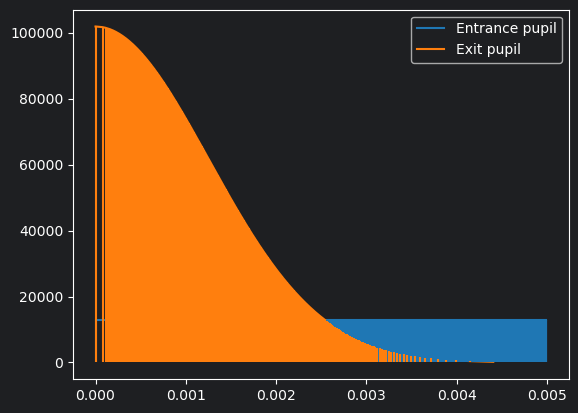

In [3]:
t = nnp.linspace(0, 1, n)[:-1]  #Fraction of total intensity in the pupil plane
f1 = 1/(nnp.pi*En_rad**2)*nnp.ones(len(t))   #Brightness distribution of the entrance pupil

# Radius function of the entrance pupil with regards to the entrance radius and the intensity fraction
def r1_(t, En_rad):
    return En_rad*nnp.sqrt(t)
# Derivative function of r1
def dr1_(t, En_rad):
    return En_rad/(2*nnp.sqrt(t))
r1 = r1_(t,En_rad)

# Radius function of the exit pupil with regards to the entrance radius, the intensity fraction, the exit radius, and if the beam is apodized
def r2_(t, Ex_rad, En_rad, apodized):
    if apodized == True:
        return nnp.sqrt(-0.5*(Ex_rad)**2*nnp.log(1-(r1_(t, En_rad)/En_rad)**2))
    if apodized == False:
        return Ex_rad*nnp.sqrt(t)
# Derivative function of r2
def dr2_(t, Ex_rad, En_rad, apodized):
    r_1 = r1_(t, En_rad)
    if apodized == True:
        g = 1-(r_1/En_rad)**2
        dg_dt = -2/(En_rad**2)*r_1*dr1_(t, En_rad)
        f = -0.5*Ex_rad**2*nnp.log(g)
        df_dt = -0.5*Ex_rad**2*dg_dt/g
        return df_dt * 1/(2*nnp.sqrt(f))
    if apodized == False:
        return Ex_rad/(2*nnp.sqrt(t))
r2 = r2_(t, Ex_rad, En_rad, apodized)
#Brightness distribution of the exit apodized pupil
if apodized == True:
    f2 = nnp.exp(-2*r2**2/Ex_rad**2)*2/(nnp.pi*Ex_rad**2)     
if apodized == False:
    f2 = 1/(nnp.pi*Ex_rad**2)*nnp.ones(len(t))

plt.plot(r1, f1, c='tab:blue', label='Entrance pupil')
plt.plot(r2, f2, c='tab:orange', label='Exit pupil')
plt.vlines(r1, 0, f1, color="tab:blue")
plt.vlines(r2, 0, f2, color="tab:orange")

#Sanity check of the total flux of the beam, normalized to 1
print(integrate.simpson(2*nnp.pi*r1*f1, r1))
print(integrate.simpson(2*nnp.pi*r2*f2, r2))

plt.legend()

#Verification of the analytical solution for dr2/dt
"""
def r2_v2(t):
    return nnp.sqrt(-0.5*(Ex_rad)**2*nnp.log(1-(r1_(t, En_rad)/En_rad)**2))

from jax import grad
plt.figure()
plt.plot(t, dr2_(t, Ex_rad, En_rad, apodized))
dr2_v2 = grad(r2_v2)
list_dr = [dr2_v2(x) for x in t]
plt.plot(t, list_dr)
#plt.plot(dr2_(t, Ex_rad, En_rad, apodized) - nnp.array(list_dr))
plt.yscale('log')
plt.show()
"""

## Differential equation resolution

Focal length M1 =  -87.68144698462613  mm
Focal length M2 =  -50.50779080190975  mm
-69.36784040091709 -69.36784040091709
-67.85192022099734 0.0


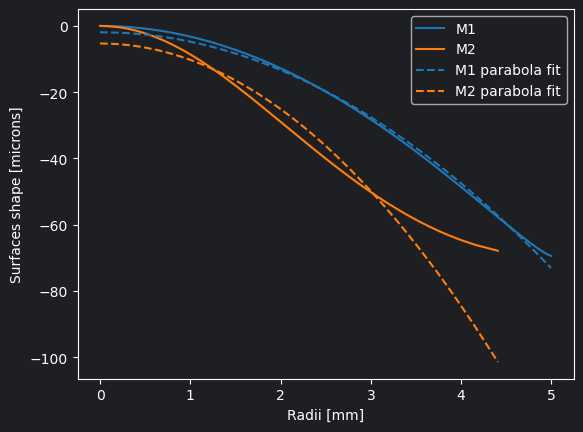

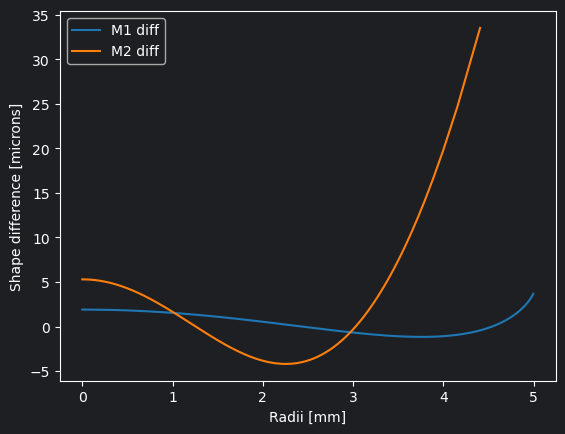

In [4]:
# Differential equation function for M1 and M2
def dM_dr(M, t):
    M1, M2 = M
    A = r2_(t, Ex_rad, En_rad, apodized) - r1_(t, En_rad)
    B = M2 - M1
    if A == 0:
        return [0, 0]
    else:
        a = (nnp.sqrt(A**2+B**2)-B)/A
        #We obtain dM1/dr1 and dM2/dr2, we need to multiply them with dr1/dt and dr2/dt to obtain dM1/dt and dM2/dt, which is necessary for odeint
        return [a*dr1_(t, En_rad), a*dr2_(t, Ex_rad, En_rad, apodized)]

#Initial values for M1 and M2
D_M1_M2 = 5*En_diam
M_0 = [0, D_M1_M2]  #Initial values are the absolute positions of the mirrors, including their distance, default distance is 5x entrance pupil diameter

#Plot of M1 and M2
results = nnp.array(integrate.odeint(dM_dr, M_0, t))
M1_results, M2_results = results[:,0], results[:,1]
M2_results = M2_results - M_0[1]
plt.plot(r1*1000, M1_results*1e6, label='M1', c='tab:blue')
plt.plot(r2*1000, M2_results*1e6, label='M2', c='tab:orange')
plt.ylabel('Surfaces shape [microns]')
plt.xlabel('Radii [mm]')

#Fit the results with a parabola
def f_parab(x,a,c):
    return a*x**2+c

popt_M1, pcov_M1 = optimize.curve_fit(f_parab, r1, M1_results)
popt_M2, pcov_M2 = optimize.curve_fit(f_parab, r2, M2_results)
plt.plot(r1*1000, f_parab(r1, popt_M1[0], popt_M1[1])*1e6, ls='--', c = 'tab:blue', label = 'M1 parabola fit')
plt.plot(r2*1000, f_parab(r2, popt_M2[0], popt_M2[1])*1e6, ls='--', c = 'tab:orange', label = 'M2 parabola fit')

#Focal distances of M1 and M2
f_M1, f_M2 = 1/(4*popt_M1[0]), 1/(4*popt_M2[0])
print('Focal length M1 = ', f_M1*1000, ' mm')
print('Focal length M2 = ', f_M2*1000, ' mm')

plt.legend()

#Plot of M1 and M2 difference with a parabola
diff_M1 = M1_results - f_parab(r1, popt_M1[0], popt_M1[1])
diff_M2 = M2_results - f_parab(r2, popt_M2[0], popt_M2[1])

plt.figure()
plt.plot(r1*1000, diff_M1*1e6, label='M1 diff', c = 'tab:blue')
plt.plot(r2*1000, diff_M2*1e6, label='M2 diff', c = 'tab:orange')
plt.ylabel('Shape difference [microns]')
plt.xlabel('Radii [mm]')
plt.legend()
print(nnp.min(M1_results*1e6), M1_results[-1]*1e6)
print(nnp.min(M2_results*1e6), nnp.max(M2_results*1e6))

## Solution check

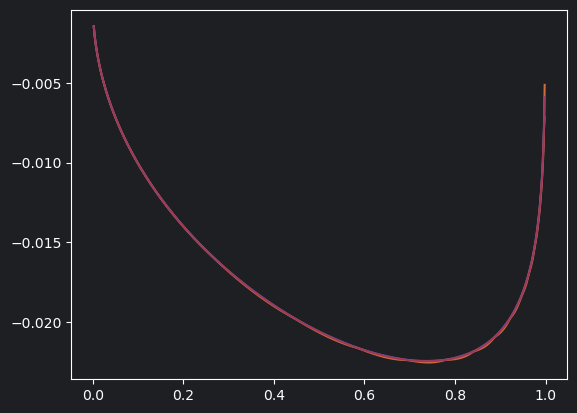

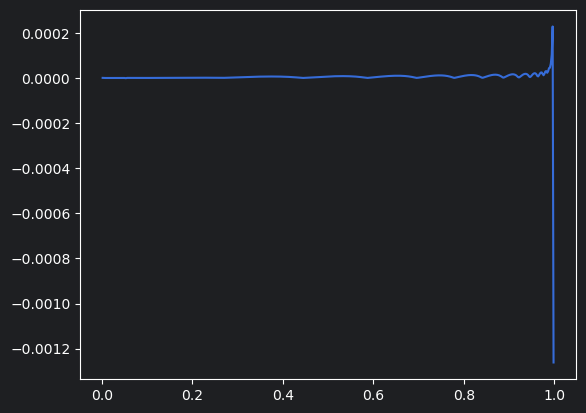

In [5]:
#Test if M1 and M2 are solutions for the differential equation
M1_f, M2_f = M1_results[1:],  (M2_results[1:] + M_0[1])

t = nnp.linspace(0, 1, n)[:-1]
t = t[1:]
dM1_dt, dM2_dt = nnp.gradient(M1_f, t), nnp.gradient(M2_f, t)
dM1_dr1, dM2_dr2 = dM1_dt/dr1_(t, En_rad), dM2_dt/dr2_(t, Ex_rad, En_rad, apodized)

A = r2 - r1
B = M2_f - M1_f
A = A[1:]
term = (nnp.sqrt(A**2+B**2)-B)/A

plt.plot(t, dM1_dr1)
plt.plot(t, dM2_dr2)
plt.plot(t, term)
plt.show()

plt.figure()
plt.plot(t, dM1_dr1 - term)
plt.show()

# Physical optical propagation using dLux

In [6]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp

# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.notebook import tqdm

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72

import Aspheres

## Definition of entrance wavefront

In [7]:
# Models some wavelengths through the system
if Wave_mono == True:
    wave = np.linspace(w_mono, w_mono, 1)
if Wave_mono == False:
    wave = np.linspace(4, 18.5, 10) * 1e-6

# Define our wavefront properties
wf_npix = 512  # Number of pixels in the wavefront
diameter = En_diam  # Diameter of the wavefront, meters

# Construct a simple circular aperture
coords = dlu.pixel_coords(wf_npix, diameter)
aperture = dlu.circle(coords, 0.5 * diameter)

# Define our image plane properties before apodization
psf_size = 1.22 * focal_length * np.min(wave) / En_diam  #PSF size [m]
psf_pixel_scale = 1  # Size of the pixels [microns]
psf_npix = int(n_pix_oversample*psf_size/(psf_pixel_scale*1e-6))  # Number of pixels in the PSF
oversample = 3  # Oversampling factor for the PSF

# Define our image plane properties after apodization
if apodized == False:  #Size of Airy disk
    psf_size_exit = 1.22 * focal_length * np.min(wave) / Ex_diam  #PSF size [m]
if apodized == True:  #1/e2 size of a gaussian
    psf_size_exit = 2*focal_length*np.min(wave)/(np.pi*Ex_diam)

psf_npix_exit = int(n_pix_oversample*psf_size_exit/(psf_pixel_scale*1e-6))  # Number of pixels in the PSF


layers = [
    (
        "aperture",
        dl.layers.TransmissiveLayer(transmission=aperture, normalise=True),
    )
]

# Construct the optics object
optics_entrance = dl.LayeredOpticalSystem(
    wf_npixels=wf_npix, diameter=diameter, layers=layers,
)
optics_entrance_psf = dl.CartesianOpticalSystem(
    wf_npix, diameter, layers, focal_length, psf_npix, psf_pixel_scale, oversample
)

if Wave_mono == True:
    pupil_entrance = optics_entrance.propagate_mono(wave[0], return_wf = True)
    pupil_entrance = pupil_entrance.real
    transmission = optics_entrance.aperture.transmission
    psf_entrance = optics_entrance_psf.propagate_mono(wave[0], return_wf = True)
    psf_entrance = psf_entrance.real
if Wave_mono == False:
    pupil_entrance = optics_entrance.propagate_mono(wave, return_wf = True)
    pupil_entrance = pupil_entrance.real
    transmission = optics_entrance.aperture.transmission
    psf_entrance = optics_entrance_psf.propagate_mono(wave, return_wf = True)
    psf_entrance = psf_entrance.real

print(optics_entrance)

LayeredOpticalSystem(
  wf_npixels=512,
  diameter=f32[],
  layers={
    'aperture': TransmissiveLayer(transmission=f32[512,512], normalise=True)
  }
)


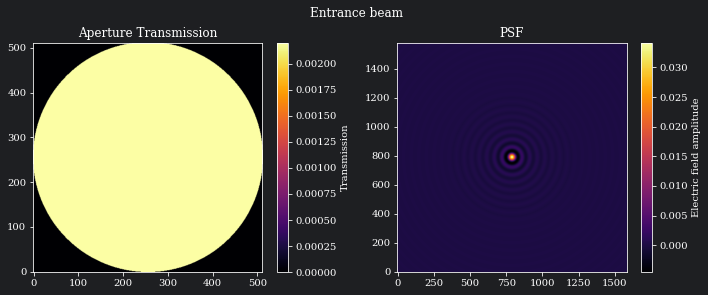

In [8]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("Entrance beam")
plt.subplot(1, 2, 1)
plt.title("Aperture Transmission")
plt.imshow(pupil_entrance)
plt.colorbar(label="Transmission")

plt.subplot(1, 2, 2)
plt.title("PSF")
plt.imshow(psf_entrance)
plt.colorbar(label="Electric field amplitude")
plt.tight_layout()
plt.show()

## Mild asphere fit of M1 and M2

In [9]:
n_asphere_terms = [4,6,8,10,12]
M1_asphere_fit = []
M1_asphere_err = []
M2_asphere_fit = []
M2_asphere_err = []

for n_i in range(len(n_asphere_terms)):
    M1_asphere_profile=Aspheres.MildAsphere.from_target_sag(
            target_rhos = r1,
            target_sags = M1_results,
            n_terms = n_asphere_terms[n_i],
            return_misfit=True,
            scale=1,
        )
    M1_asphere_fit.append(M1_asphere_profile[0].sag(r1))
    M1_asphere_err.append(M1_asphere_profile[1])
    
    M2_asphere_profile=Aspheres.MildAsphere.from_target_sag(
            target_rhos = r2,
            target_sags = M2_results,
            n_terms =  n_asphere_terms[n_i],
            return_misfit=True,
            scale=1,
        )
    M2_asphere_fit.append(M2_asphere_profile[0].sag(r2))
    M2_asphere_err.append(M2_asphere_profile[1])

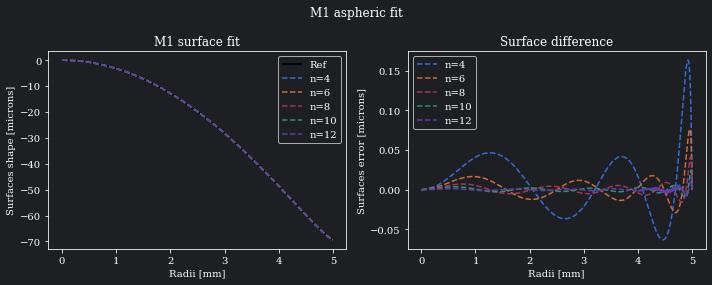

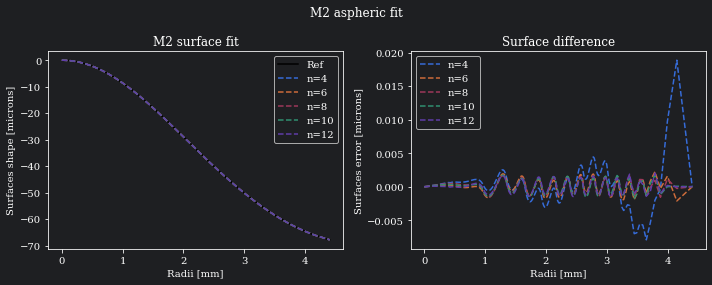

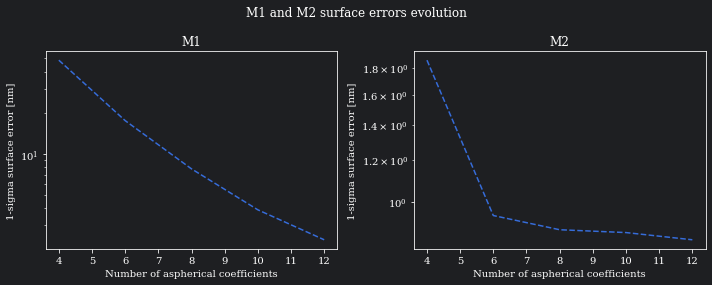

In [10]:
# Plot the results for M1
plt.figure(figsize=(10, 4))
plt.suptitle("M1 aspheric fit")
plt.subplot(1, 2, 1)
plt.title("M1 surface fit")
plt.ylabel('Surfaces shape [microns]')
plt.xlabel('Radii [mm]')
plt.plot(r1*1000, M1_results*1e6, c='k', label='Ref')
for n_i in range(len(n_asphere_terms)):
    plt.plot(r1*1000, M1_asphere_fit[n_i]*1e6, label='n='+str(n_asphere_terms[n_i]), ls='--')
plt.legend()    

plt.subplot(1, 2, 2)
plt.title("Surface difference")
plt.ylabel('Surfaces error [microns]')
plt.xlabel('Radii [mm]')
for n_i in range(len(n_asphere_terms)):
    plt.plot(r1*1000, M1_asphere_err[n_i]*1e6, label='n='+str(n_asphere_terms[n_i]), ls='--')
plt.legend()    

plt.tight_layout()
plt.show()

# Plot the results for M2
plt.figure(figsize=(10, 4))
plt.suptitle("M2 aspheric fit")
plt.subplot(1, 2, 1)
plt.title("M2 surface fit")
plt.ylabel('Surfaces shape [microns]')
plt.xlabel('Radii [mm]')
plt.plot(r2*1000, M2_results*1e6, c='k', label='Ref')
for n_i in range(len(n_asphere_terms)):
    plt.plot(r2*1000, M2_asphere_fit[n_i]*1e6, label='n='+str(n_asphere_terms[n_i]), ls='--')
plt.legend()    

plt.subplot(1, 2, 2)
plt.title("Surface difference")
plt.ylabel('Surfaces error [microns]')
plt.xlabel('Radii [mm]')
for n_i in range(len(n_asphere_terms)):
    plt.plot(r2*1000, M2_asphere_err[n_i]*1e6, label='n='+str(n_asphere_terms[n_i]), ls='--')
plt.legend()    

plt.tight_layout()
plt.show()

# Plot the evolution of surface errors with n_asphere
plt.figure(figsize=(10, 4))
plt.suptitle("M1 and M2 surface errors evolution")
plt.subplot(1, 2, 1)
plt.title("M1")
plt.ylabel('1-sigma surface error [nm]')
plt.xlabel('Number of aspherical coefficients')
plt.yscale('log')
M1_err = []
for n_i in range(len(n_asphere_terms)):
    M1_err.append(np.std(M1_asphere_err[n_i]*1e9))

plt.plot(n_asphere_terms, M1_err, ls='--')  

plt.subplot(1, 2, 2)
plt.title("M2")
plt.ylabel('1-sigma surface error [nm]')
plt.xlabel('Number of aspherical coefficients')
plt.yscale('log')
M2_err = []
for n_i in range(len(n_asphere_terms)):
    M2_err.append(np.std(M2_asphere_err[n_i]*1e9))

plt.plot(n_asphere_terms, M2_err, ls='--')

plt.tight_layout()
plt.show()

## PIAA system construction

In [11]:
n_asphere_term = 12

piaa_profile_1 = Aspheres.MildAsphere.from_target_sag(
                target_rhos = r1,
                target_sags = M1_results,
                n_terms = n_asphere_term,
                scale=1,
            )

piaa_profile_2=Aspheres.MildAsphere.from_target_sag(
                target_rhos = r2,
                target_sags = -M2_results,
                n_terms =  n_asphere_term,
                scale=1,
            )

#print('Focal length M1 = ', f_M1*1000, ' mm')
print('Basis radius M1 = ', 1/piaa_profile_1.c_bfs , ' m')
print('Aspherical coeffs M1 = ', piaa_profile_1.coeffs)
#print('Focal length M2 = ', f_M2*1000, ' mm')
print('Basis radius M2 = ', 1/piaa_profile_2.c_bfs , ' m')
print('Aspherical coeffs M2 = ', piaa_profile_2.coeffs)

PIAA = Aspheres.PIAAset(
        piaa_optic_1=Aspheres.AsphericMirror(
            piaa_profile_1,
            coords=coords,
        ),
        piaa_optic_2=Aspheres.AsphericMirror(
            piaa_profile_2,
            coords=coords,
        ),
        distance=D_M1_M2,
    )

layers = [
    ("aperture",
    dl.TransmissiveLayer(aperture, normalise=True)),
    PIAA,
]


optics_exit = dl.LayeredOpticalSystem(
    wf_npixels=wf_npix, diameter=diameter, layers=layers,
)
optics_exit_psf = dl.CartesianOpticalSystem(
    wf_npix, diameter, layers, focal_length, psf_npix_exit, psf_pixel_scale, oversample
)

Basis radius M1 =  -0.17987235  m
Aspherical coeffs M1 =  [-2.7774606e-05  9.7600159e-06 -5.8979140e-06  3.8004955e-06
 -2.6263758e-06  1.8385106e-06 -1.2992994e-06  8.9826057e-07
 -6.0182055e-07  3.7473316e-07 -1.9994442e-07  7.9638248e-08]
Basis radius M2 =  0.14309838  m
Aspherical coeffs M2 =  [ 5.9959686e-05  1.2283343e-05  1.7317572e-06  1.4239515e-06
 -8.7051808e-07  8.6186515e-07 -7.3406721e-07  5.5488584e-07
 -3.8241339e-07  2.2113984e-07 -1.0325195e-07  3.4727389e-08]


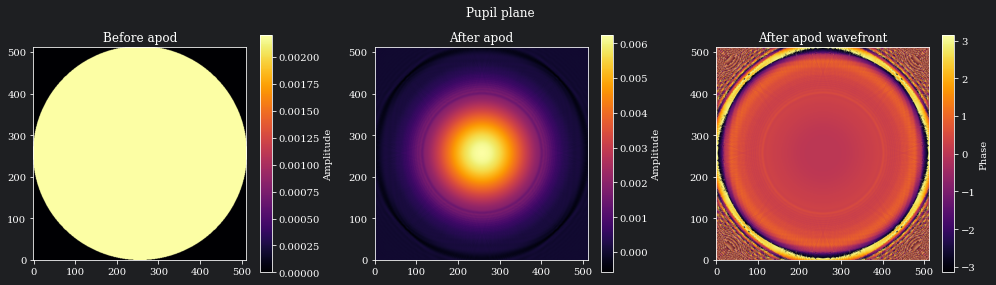

0.9999936
0.96505773


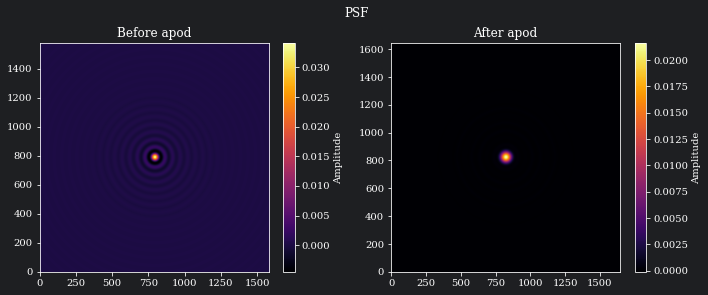

In [12]:
# Plot the exit pupil and focus
if Wave_mono == True:
    pupil_exit = optics_exit.propagate_mono(wave[0], return_wf = True)
    pupil_exit = pupil_exit.real
    pupil_exit_wf = optics_exit.propagate_mono(wave[0], return_wf = True)
    pupil_exit_wf = pupil_exit_wf.phase
    psf_exit = optics_exit_psf.propagate_mono(wave[0], return_wf = True)
    psf_exit = psf_exit.real
if Wave_mono == False:
    pupil_exit = optics_exit.propagate_mono(wave, return_wf = True)
    pupil_exit = pupil_exit.real
    pupil_exit_wf = pupil_exit.phase
    psf_exit = optics_exit_psf.propagate_mono(wave, return_wf = True)
    psf_exit = psf_exit.real

#Pupil plane
plt.figure(figsize=(14, 4))
plt.suptitle("Pupil plane")

plt.subplot(1, 3, 1)
plt.title("Before apod")
plt.imshow(pupil_entrance, norm=colors.Normalize(vmin=np.min(pupil_entrance), vmax=np.max(pupil_entrance)))
plt.colorbar(label="Amplitude")

plt.subplot(1, 3, 2)
plt.title("After apod")
plt.imshow(pupil_exit, norm=colors.Normalize(vmin=np.min(pupil_exit), vmax=np.max(pupil_exit)))
plt.colorbar(label="Amplitude")

plt.subplot(1, 3, 3)
plt.title("After apod wavefront")
if Wave_mono == True:
    plt.imshow(pupil_exit_wf)
if Wave_mono == False:
    plt.imshow(pupil_exit_wf[0])
plt.colorbar(label="Phase")

plt.tight_layout()
plt.show()

print(np.sum(pupil_entrance**2))
print(np.sum(pupil_exit**2))


#Image plane
plt.figure(figsize=(10, 4))
plt.suptitle("PSF")

plt.subplot(1, 2, 1)
plt.title("Before apod")
plt.imshow(psf_entrance, norm=colors.Normalize(vmin=np.min(psf_entrance), vmax=np.max(psf_entrance)))
plt.colorbar(label="Amplitude")

plt.subplot(1, 2, 2)
plt.title("After apod")
plt.imshow(psf_exit, norm=colors.Normalize(vmin=np.min(psf_exit), vmax=np.max(psf_exit)))
plt.colorbar(label="Amplitude")

plt.tight_layout()
plt.show()

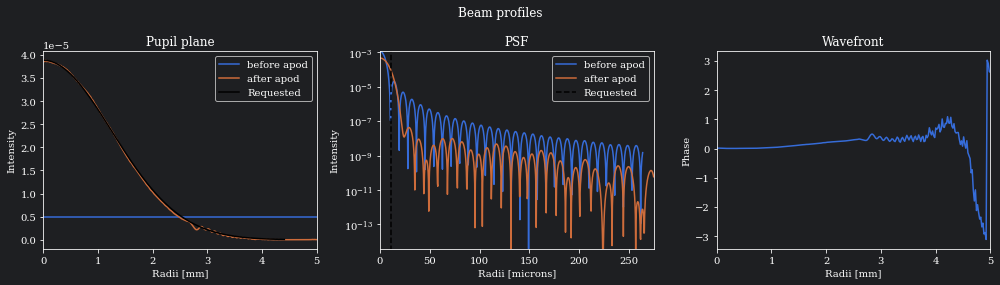

In [13]:
#Analysis of the gaussian profile
pupil_exit_profile = pupil_exit[int(0.5*wf_npix),:]
pupil_exit_wf_profile = pupil_exit_wf[int(0.5*wf_npix),:]
psf_exit_profile = psf_exit[int(0.5*psf_npix_exit*oversample),:]
pupil_entrance_profile = pupil_entrance[int(0.5*wf_npix),:]
psf_entrance_profile = psf_entrance[int(0.5*psf_npix*oversample),:]

# X-axes in length for the image and pupil plane 
x_axis_pupil = np.linspace(0, wf_npix, wf_npix)*diameter/wf_npix - diameter/2
x_axis_psf = np.linspace(0, psf_npix, psf_npix*oversample)*psf_pixel_scale - psf_npix*psf_pixel_scale/2
x_axis_psf *= 1e-6
x_axis_psf_exit = np.linspace(0, psf_npix_exit, psf_npix_exit*oversample)*psf_pixel_scale - psf_npix_exit*psf_pixel_scale/2
x_axis_psf_exit *= 1e-6

# Fit with a gaussian with the defined waist
if apodized == True:
    A=np.max(pupil_exit_profile**2)
    G_fit = A*np.exp(-2*r2**2/(Ex_rad)**2)

plt.figure(figsize=(14, 4))
plt.suptitle("Beam profiles")
plt.subplot(1, 3, 1)
plt.title("Pupil plane")
plt.plot(x_axis_pupil*1000, pupil_entrance_profile**2, label='before apod')
plt.plot(x_axis_pupil*1000, pupil_exit_profile**2, label='after apod')
if apodized == True:
    plt.plot(r2*1000, G_fit, color="k", label="Requested")
plt.ylabel('Intensity')
plt.xlabel("Radii [mm]")
plt.xlim(0, np.max(x_axis_pupil*1000))
plt.legend()

plt.subplot(1, 3, 2)
plt.title("PSF")
plt.plot(x_axis_psf*1e6, psf_entrance_profile**2, label='before apod') 
plt.plot(x_axis_psf_exit*1e6, psf_exit_profile**2, label='after apod')
plt.vlines(psf_size_exit*1e6, 1e-15, 1e-0, ls="--", color="k", label="Requested")
plt.yscale("log")
plt.xlim(0, max([np.max(x_axis_psf_exit), np.max(x_axis_psf)])*1e6)
plt.ylim(np.min(psf_entrance_profile**2), np.max(psf_entrance_profile**2))
plt.ylabel('Intensity')
plt.xlabel("Radii [microns]")
plt.legend()

plt.subplot(1, 3, 3)
plt.title("Wavefront")
plt.plot(x_axis_pupil*1e3, pupil_exit_wf_profile, label='after apod')
plt.xlim(0, np.max(x_axis_pupil*1e3))
plt.yscale("linear")
plt.ylabel('Phase')
plt.xlabel("Radii [mm]")

plt.tight_layout()
plt.show()

## Results check with Zemax

Comparison for apodized beam from 10mm to 10mm diameter with 4 fitting parameters

In [14]:
def read_zemax_sag(file):
    #Find the beginnning of the table
    f = open(file, 'r', encoding="utf-16")
    i = 0
    while ('X-Coordinate' in f.readline()) == False and i<1000:
        i += 1
    f.close()

    #Read and store the sag table
    conv = lambda s: float(s.replace(',', '.'))
    data = nnp.genfromtxt(file, encoding = "utf-16", delimiter = "", skip_header = i+1, converters={0: conv, 1: conv, 2: conv})
    data = np.array(data)
    return data[:,0], data[:,2]

In [15]:
#Zemax's results from dLux without optimization
pwd_sag = 'Zemax_sag/'
r_1_zemax, f_M1_zemax = read_zemax_sag(pwd_sag + "zemax_from_dLux_M1.txt")
r_1_zemax, f_M1_zemax = r_1_zemax[r_1_zemax >= 0], f_M1_zemax[r_1_zemax >= 0]
r_2_zemax, f_M2_zemax = read_zemax_sag(pwd_sag + "zemax_from_dLux_M2.txt")
r_2_zemax, f_M2_zemax = r_2_zemax[r_2_zemax >= 0], f_M2_zemax[r_2_zemax >= 0]

plt.figure()
plt.plot(r2*1000, M2_results*1e6, label='M2_th', c = 'k', ls='dashed')
plt.plot(r_2_zemax*1000, f_M2_zemax*1e6, label='M2_zemax', c = 'tab:orange')
#plt.plot(r2*1000, -piaa_profile_2.sag(r2)*1e6, label='M2_dLux', c = 'tab:orange', ls='dotted')
plt.plot(r1*1000, M1_results*1e6, label='M1_th', c = 'k', ls='dashed')
plt.plot(r_1_zemax*1000, f_M1_zemax*1e6, label='M1_zemax', c = 'tab:blue')
#plt.plot(r1*1000, piaa_profile_1.sag(r1)*1e6, label='M1_dLux', c = 'tab:blue', ls='dotted')
plt.ylabel('Surfaces shape [microns]')
plt.xlabel('Radii [mm]')
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'Zemax_sag/zemax_from_dLux_M1.txt'

In [ ]:
# Wavefront comparison
def read_zemax_wf(file):
    #Find the beginnning of the table
    f = open(file, 'r', encoding="utf-16")
    i = 0
    while ('Center point is' in f.readline()) == False and i<1000:
        i += 1
    f.close()

    #Read and store the wavefront map
    size_grid = 128
    conv = lambda s: float(s.replace(',', '.'))
    data = nnp.genfromtxt(file, encoding = "utf-16", delimiter = "", skip_header = i+1, converters={i: conv for i in range(size_grid)})
    data = np.array(data)
    return data
    
zemax_exit_wf = read_zemax_wf("Zemax_ wavefront_map_dLux.txt")
zemax_exit_wf_profile = zemax_exit_wf[64,:]
x_axis_wf_zemax = np.linspace(-np.max(r2),np.max(r2),128)

plt.title("Wavefront")
if Wave_mono == True:
    plt.plot(x_axis_pupil*1e3, pupil_exit_wf_profile, label='dLux', color="tab:blue")
if Wave_mono == False:
    plt.plot(x_axis_pupil*1e3, pupil_exit_wf_profile[0], label='dLux', color="tab:blue")
plt.plot(x_axis_wf_zemax*1e3, -zemax_exit_wf_profile, label='Zemax', color="tab:orange")
plt.xlim(0,np.max(x_axis_pupil*1e3))
plt.yscale("linear")
plt.ylabel('Phase')
plt.xlabel("Radii [mm]")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Zemax's results from dLux after Zemax optimization
pwd_sag = 'Zemax_sag/'
r_1_zemax, f_M1_zemax = read_zemax_sag(pwd_sag + "zemax_opti_M1.txt")
r_1_zemax, f_M1_zemax = r_1_zemax[r_1_zemax >= 0], f_M1_zemax[r_1_zemax >= 0]
r_2_zemax, f_M2_zemax = read_zemax_sag(pwd_sag + "zemax_opti_M2.txt")
r_2_zemax, f_M2_zemax = r_2_zemax[r_2_zemax >= 0], f_M2_zemax[r_2_zemax >= 0]

M1_zemax_fit = Aspheres.MildAsphere.from_target_sag(
                            target_rhos = r_1_zemax,
                            target_sags = f_M1_zemax,
                            n_terms =  n_asphere_term,
                            scale=1,
                        )

M2_zemax_fit = Aspheres.MildAsphere.from_target_sag(
                            target_rhos = r_2_zemax,
                            target_sags = -f_M2_zemax,
                            n_terms =  n_asphere_term,
                            scale=1,
                        )

print('Aspherical coeffs M1 = ', M1_zemax_fit.coeffs)
print('Aspherical coeffs M2 = ', M2_zemax_fit.coeffs)

plt.figure()
plt.plot(r2*1000, -M2_results*1e6, label='M2_th', c = 'k', ls='dashed')
#plt.plot(r_2_zemax*1000, -f_M2_zemax*1e6, label='M2_zemax', c = 'tab:orange')
plt.plot(r2*1000, M2_zemax_fit.sag(r2)*1e6, label='M2_dLux', c = 'tab:orange')
plt.plot(r1*1000, M1_results*1e6, label='M1_th', c = 'k', ls='dashed')
#plt.plot(r_1_zemax*1000, f_M1_zemax*1e6, label='M1_zemax', c = 'tab:blue')
plt.plot(r1*1000, M1_zemax_fit.sag(r1)*1e6, label='M1_dLux', c = 'tab:blue')
plt.ylabel('Surfaces shape [microns]')
plt.xlabel('Radii [mm]')
plt.legend()

plt.figure()
plt.plot(r2*1000, M2_zemax_fit.sag(r2)*1e6 + M2_results*1e6, label='M2', c = 'tab:orange')
plt.plot(r1*1000, M1_zemax_fit.sag(r1)*1e6 - M1_results*1e6, label='M1', c = 'tab:blue')
plt.ylabel('Deviation after optimization [microns]')
plt.xlabel('Radii [mm]')
plt.legend()

# Coupling efficiency calculation

In [ ]:
def coupling_efficiency(mfd, beam_dia, wl, f, pointing, shear):
    """
    Calculate the coupling efficiency between a Gaussian beam and a single-mode fiber.
    Parameters:
    mfd : float
        Mode field diameter of the fiber (in meters).
    beam_dia : float
        Diameter of the Gaussian beam, where the intensity drops to 1/e^2 (in meters).
    wl : float
        Wavelength of the light (in meters).
    f : float
        Focal length of the lens (in meters).
    pointing : float
        Pointing error (in radians).
    shear : float
        Shear error (in meters).
    Returns:
    float
        Coupling efficiency (between 0 and 1).
    """
    w1 = mfd/2 # mode field radius (m)
    w0 = beam_dia/2 # beam radius (m)

    factor = 4 * (f * np.pi * w0 * w1 * wl)**2 / (np.pi**2 * w0**2 * w1**2 + f**2 * wl**2)**2
    exponent = - 2 * np.pi * (shear**2 * np.pi * w1**2 + f**2 * np.pi * w0**2 * pointing**2) / (np.pi**2 * w0**2 * w1**2 + f**2 * wl**2)

    return factor * np.exp(exponent)

In [ ]:
# Plot of the fiber mode, the psf from dLux, and the equivalent Airy disk for comparison

X, Y = np.meshgrid(x_axis_psf_exit, x_axis_psf_exit)

# Model of fiber mode
Mode_std = float(mfd/4)
Fiber_model = modeling.functional_models.Gaussian2D(amplitude = float(1/(Mode_std*np.sqrt(2*np.pi))), x_stddev = Mode_std, y_stddev = Mode_std)
Fiber_1D = Fiber_model(x_axis_psf_exit, 0) #Intensity
Fiber_2D = Fiber_model(X,Y) #Intensity

# PSF from dLux (apodized or not)
PSF_1D_dLux = psf_exit_profile**2/nnp.trapezoid(psf_exit_profile**2, x_axis_psf_exit) #Intensity
PSF_2D_dLux = psf_exit #Amplitude

# Model for Airy disk in 1D
x = np.pi * x_axis_psf_exit * Ex_diam / w_mono / focal_length
PSF_model = (special.j1(x)/x)**2
PSF_model *= 4*np.max(PSF_1D_dLux)  
PSF_1D = PSF_model   #Intensity

# Model for Airy disk in 2D
Fiber_2D = Fiber_model(X,Y)
R = np.sqrt(X**2 + Y**2)
X_array = np.pi * R * Ex_diam / w_mono / focal_length
PSF_2D = special.j1(X_array)/X_array
PSF_2D = PSF_2D.at[nnp.isnan(PSF_2D)].set(0.5)  #Amplitude

plt.plot(x_axis_psf_exit*1e6, PSF_1D_dLux, label="PSF dLux")
plt.plot(x_axis_psf_exit*1e6, Fiber_1D, color="tab:orange", label="Fiber mode")
plt.plot(x_axis_psf_exit*1e6, PSF_1D, color="k",ls="dotted", label="Airy disk model")
#plt.vlines(mfd/2*1e6, 1e-2, np.max(Fiber_1D), color="tab:orange", ls="--")
#plt.vlines(psf_size_exit*1e6, np.min(PSF_1D_dLux), np.max(Fiber_1D), ls="--", color="tab:blue")
#plt.hlines(np.max(Fiber_1D)*np.exp(-2), 0, np.max(x_axis*1e6)/2, color="tab:orange", ls="--")
plt.xlabel("Radii [microns]")
plt.ylabel("Intensity")
plt.xlim(0, np.max(x_axis_psf_exit*1e6)/2)
plt.ylim(np.min(PSF_1D_dLux), max([np.max(PSF_1D_dLux),np.max(Fiber_1D)]))
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
# Computation of the coupling efficiency 

pointing = 0.0  # Pointing error (rad)
shear = 0.0  # Shear error (m)

# Ideal coupling efficiency
NA = Ex_diam/(2*focal_length)
beta = np.pi*mfd/w_mono*NA/2
if apodized == False:
    print("Ideal Ceff = ", 2*((np.exp(-beta**2)-1)/beta)**2)
if apodized == True:
    print("Ideal Ceff = ", coupling_efficiency(mfd, Ex_diam, w_mono, focal_length, pointing, shear))

# Coupling efficiency from Airy disk model
E_psf, E_g = PSF_2D, np.sqrt(Fiber_2D)
coupling = (np.sum(E_psf * E_g))**2/(np.sum(E_psf**2) * np.sum(E_g**2)) 
print("Ceff Airy disk = ", coupling)

# Coupling efficiency from dLux
E_psf, E_g = psf_exit, np.sqrt(Fiber_2D)
coupling = (np.sum(E_psf * E_g))**2/(np.sum(E_psf**2) * np.sum(E_g**2)) 
print("Ceff dLux = ", coupling)